In [1]:
import numpy  as np
import pandas as pd
import re,os,sys

In [3]:
path = r"LMD_PancreaticCancer_Quant_Spectranout_RAW_log2-mcpcounter-sigmtx_Joe2_nodup.tsv"

In [4]:
data = pd.read_csv(path,sep="\t")

In [5]:
data

,Unnamed: 0,400_PDAC_1,400_PDAC_2,400_PDAC_3,400_PDAC_4,400_PDAC_5,400_PDAC_6,400_PDAC_7,400_PDAC_8,008_PDAC_1,...,628_IPMN_3,400_NAT_1,400_NAT_2,400_NAT_3,175_NAT_1,175_NAT_2,175_NAT_3,504_NAT_1,504_NAT_2,504_NAT_3
0,Acinar,988.964656,859.082539,1042.450293,838.577307,1165.743575,1125.518123,1160.851850,1099.364445,1182.923739,...,1293.761663,1116.393210,1114.629622,1021.834081,1285.674861,1316.028175,941.663853,1315.418176,1302.130763,1247.226208
1,Activated_CD4,445.377038,403.449637,525.044683,427.265040,584.805867,527.559552,553.657885,490.214744,557.007044,...,556.278765,535.832796,509.646941,445.680513,510.034408,550.904769,407.352314,591.914404,590.479614,498.166695
2,B cell,782.598367,591.051277,847.173192,469.747544,691.003874,769.501033,690.254497,595.130005,672.402886,...,595.109800,597.310936,573.241709,494.716415,577.565091,617.214138,426.744515,870.805789,952.112684,710.431511
3,CD4,1041.279055,923.886949,1132.634268,1023.969498,1261.685154,1052.967165,1212.101382,1152.182261,1105.369889,...,1291.072491,975.851945,910.613270,673.189153,790.368971,852.304353,792.847127,987.706530,990.515873,862.741428
4,CD8,313.720241,275.638512,374.904671,276.837504,429.983399,382.859916,408.478812,341.135622,436.447302,...,393.538200,417.363559,403.060868,365.026508,430.316570,444.737322,291.468250,476.787144,459.788539,413.157409
5,Effector_CD8,167.761974,169.120534,195.419157,189.892039,232.316738,193.202091,261.124918,181.598188,265.316219,...,240.516347,205.494864,196.831099,187.577095,196.747644,211.682743,144.154480,207.418530,223.994087,175.063683
6,Endothelial,567.000333,506.180807,593.641739,461.030129,655.593820,614.070060,627.394120,602.793626,600.059935,...,571.642827,482.116704,476.766240,497.163923,619.669364,596.171081,464.429651,605.493432,636.824978,552.222134
7,Epithelial_cancer,1145.575221,983.992613,1186.531049,1010.173315,1387.125363,1285.566552,1325.050485,1295.931537,1353.225205,...,1481.743442,1420.996585,1431.700021,1027.661773,1320.025924,1378.232519,1043.200026,1269.400956,1279.855647,1218.759131
8,Epithelial_normal,1012.446507,895.428281,1053.646608,876.565562,1230.567366,1186.172630,1193.098740,1145.304221,1206.944386,...,1317.442430,1304.557111,1293.463628,1158.782422,1352.394295,1402.419724,966.238891,1437.108615,1463.560337,1358.463394
9,Fibroblast,1019.772771,861.976313,1092.282713,718.550251,1087.984652,1112.497463,1013.299829,931.451432,902.145581,...,829.873764,861.827470,797.993849,829.185274,1059.156140,1067.954049,734.327928,1189.673685,1300.841350,1091.230463


In [6]:
df = pd.DataFrame(data).set_index("Unnamed: 0") 

df_percentage = df.div(df.sum(axis=0), axis=1) * 100

In [7]:
df_percentage

,400_PDAC_1,400_PDAC_2,400_PDAC_3,400_PDAC_4,400_PDAC_5,400_PDAC_6,400_PDAC_7,400_PDAC_8,008_PDAC_1,008_PDAC_2,...,628_IPMN_3,400_NAT_1,400_NAT_2,400_NAT_3,175_NAT_1,175_NAT_2,175_NAT_3,504_NAT_1,504_NAT_2,504_NAT_3
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Acinar,9.353223,9.377846,9.218953,9.423492,9.396398,9.619591,9.697209,10.111482,10.341952,10.593034,...,11.048154,10.316030,10.623822,10.855264,11.216277,11.315292,10.927894,10.597406,10.166715,11.025284
Activated_CD4,4.212194,4.404104,4.643255,4.801380,4.713789,4.508952,4.624997,4.508785,4.869748,5.230454,...,4.750375,4.951362,4.857576,4.734604,4.449560,4.736714,4.727274,4.768641,4.610319,4.403715
B cell,7.401495,6.451985,7.492012,5.278777,5.569791,6.576780,5.766060,5.473750,5.878620,4.905037,...,5.081975,5.519451,5.463714,5.255527,5.038700,5.306846,4.952318,7.015474,7.433860,6.280103
CD4,9.847991,10.085258,10.016499,11.506832,10.169729,8.999512,10.125323,10.597278,9.663922,7.028544,...,11.025190,9.017359,8.679289,7.151499,6.895210,7.328166,9.200894,7.957262,7.733703,7.626499
CD8,2.967038,3.008902,3.315485,3.110955,3.465853,3.272232,3.412239,3.137619,3.815730,4.189752,...,3.360643,3.856647,3.841677,3.877791,3.754098,3.823879,3.382453,3.841141,3.589915,3.652247
Effector_CD8,1.586624,1.846140,1.728198,2.133907,1.872574,1.651262,2.181314,1.670262,2.319581,2.301525,...,2.053904,1.898875,1.876048,1.992690,1.716434,1.820061,1.672895,1.671026,1.748890,1.547535
Endothelial,5.362457,5.525529,5.249896,5.180815,5.284370,5.248341,5.240954,5.544237,5.246146,5.552884,...,4.881578,4.454999,4.544182,5.281528,5.406020,5.125916,5.389649,4.878038,4.972172,4.881557
Epithelial_cancer,10.834382,10.741379,10.493138,11.351798,11.180832,10.987495,11.068847,11.919422,11.830848,13.303917,...,12.653436,13.130717,13.645901,10.917173,11.515957,11.850129,12.106209,10.226677,9.992796,10.773639
Epithelial_normal,9.575305,9.774600,9.317968,9.850384,9.918906,10.137994,9.966584,10.534016,10.551958,11.568307,...,11.250377,12.054758,12.328335,12.310109,11.798340,12.058092,11.213084,11.577780,11.427117,12.008603


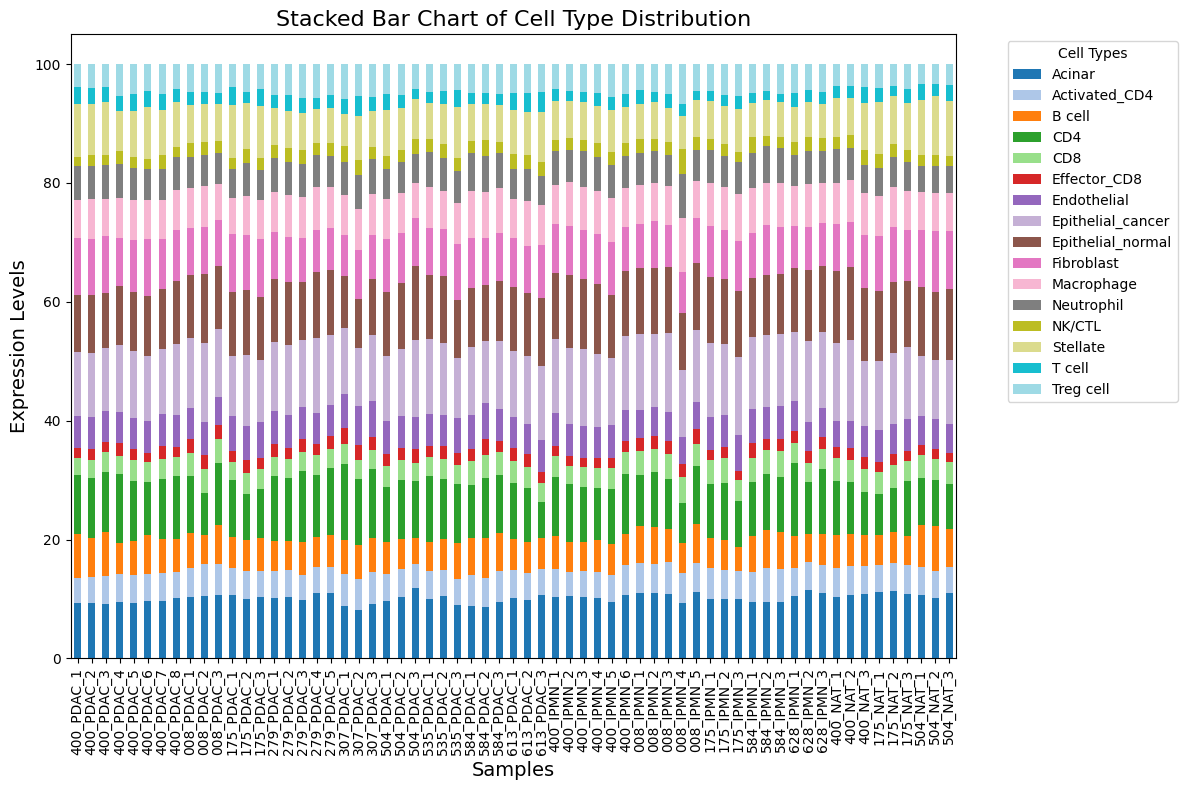

In [7]:
# Convert to a DataFrame
import matplotlib.pyplot as plt


# Create a stacked bar chart
df_percentage.T.plot(kind="bar", stacked=True, figsize=(12, 8), colormap="tab20")
plt.title("Stacked Bar Chart of Cell Type Distribution", fontsize=16)
plt.xlabel("Samples", fontsize=14)
plt.ylabel("Expression Levels", fontsize=14)
plt.legend(title="Cell Types", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [1]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
# Assuming `df_percentage` contains your percentage-normalized data
pca = PCA(n_components=2)  # Choose the number of components you want
pca_result = pca.fit_transform(df_percentage.T)  # Transpose to analyze samples


In [9]:
pca_df = pd.DataFrame(
    pca_result, columns=['PC1', 'PC2'], index=df_percentage.columns
)


In [10]:
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance: {explained_variance}")


Explained Variance: [0.38344718 0.30540286]


In [11]:
pca_df.head(2)

,PC1,PC2
400_PDAC_1,1.835671,-2.943014
400_PDAC_2,1.170069,-2.515759


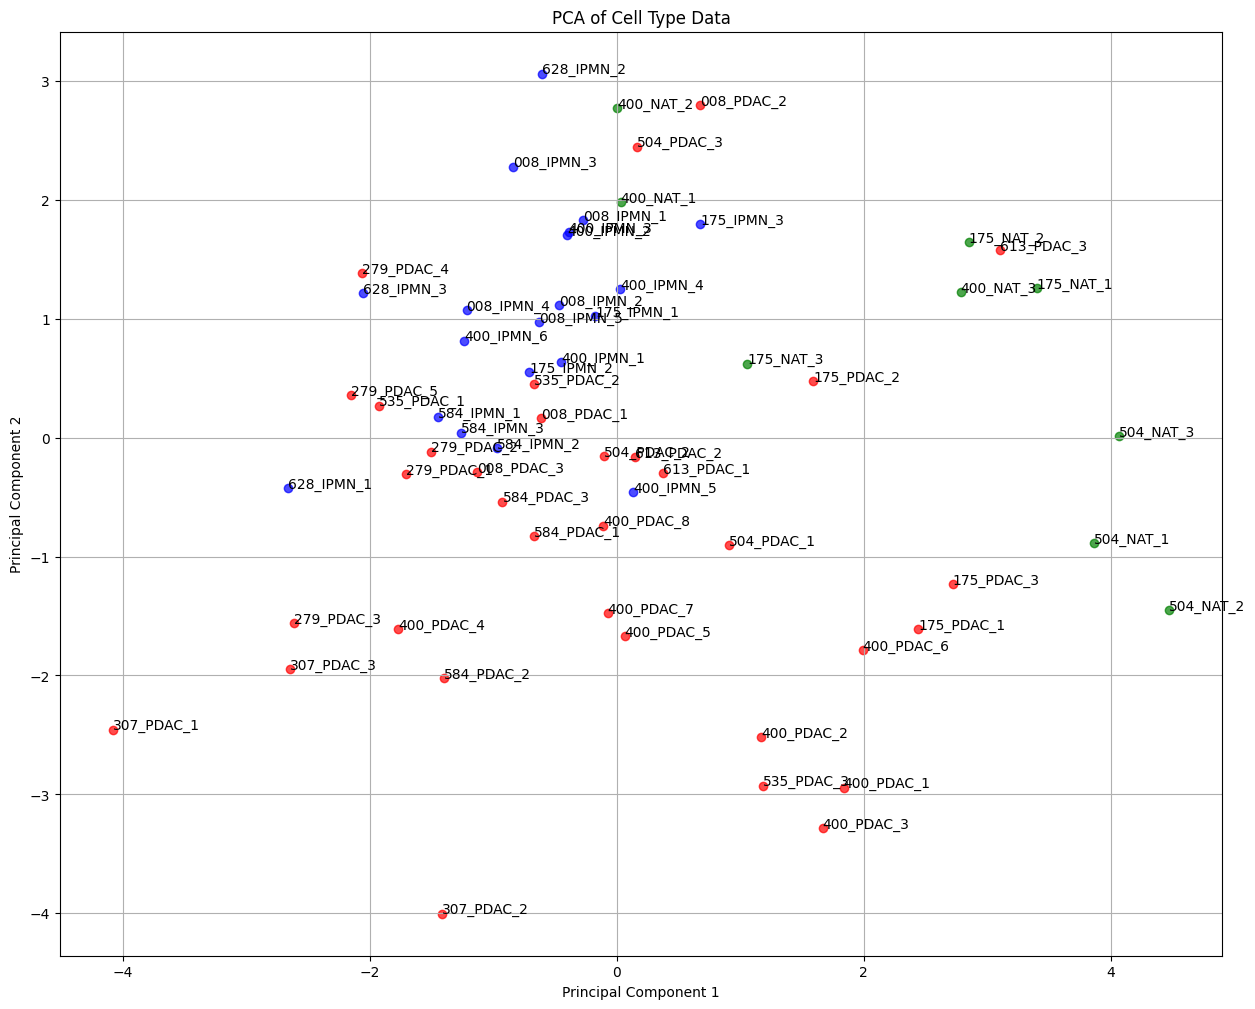

In [12]:
plt.figure(figsize=(15, 12))
plt.scatter(pca_df[pca_df.index.str.contains('PDAC')]['PC1'], pca_df[pca_df.index.str.contains('PDAC')]['PC2'], c='red', alpha=0.7)
plt.scatter(pca_df[pca_df.index.str.contains('IPMN')]['PC1'], pca_df[pca_df.index.str.contains('IPMN')]['PC2'], c='blue', alpha=0.7)
plt.scatter(pca_df[pca_df.index.str.contains('NAT')]['PC1'], pca_df[pca_df.index.str.contains('NAT')]['PC2'], c='green', alpha=0.7)
for sample, (x, y) in pca_df.iterrows():
    plt.text(x, y, sample, fontsize=10)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Cell Type Data')
plt.grid()
plt.show()


In [13]:
loadings = pd.DataFrame(
    pca.components_.T,  # Transpose to align features with PCs
    index=df_percentage.index,  # Feature names (cell types)
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]  # PC names
)
print(loadings)


                        PC1       PC2
Unnamed: 0                           
Acinar             0.107746  0.356682
Activated_CD4     -0.079920  0.000833
B cell             0.098910 -0.255390
CD4               -0.562525 -0.400770
CD8               -0.000882  0.077652
Effector_CD8      -0.079584 -0.014201
Endothelial       -0.014600 -0.126519
Epithelial_cancer -0.159054  0.510136
Epithelial_normal  0.202350  0.457292
Fibroblast         0.393713 -0.199252
Macrophage        -0.082531  0.048393
Neutrophil        -0.155052 -0.028729
NK/CTL            -0.057897  0.046698
Stellate           0.563776 -0.296663
T cell             0.087016 -0.146256
Treg cell         -0.261466 -0.029906


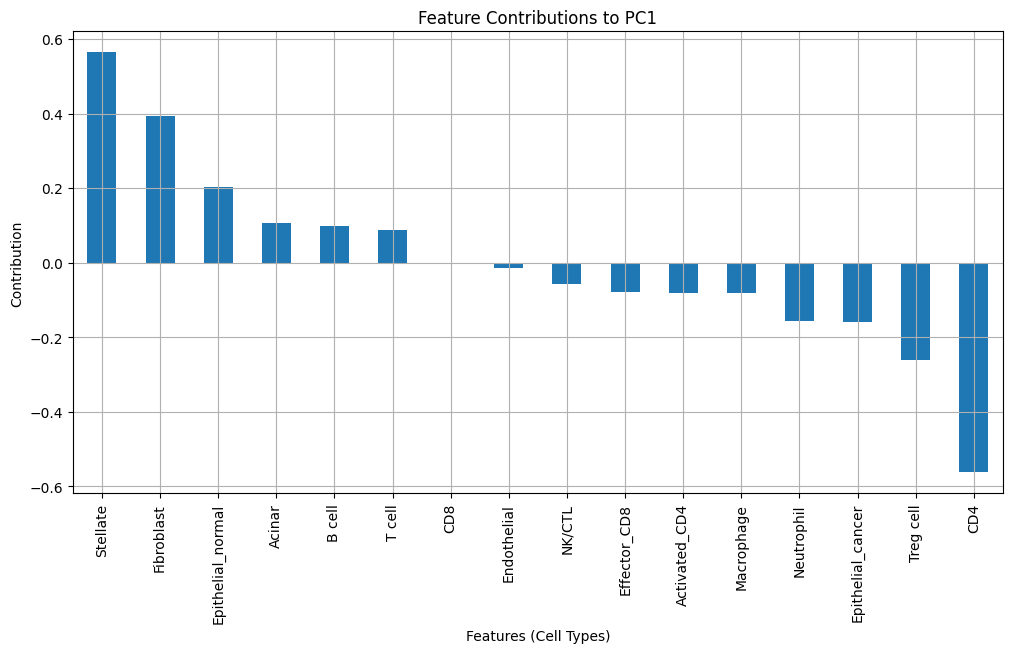

In [14]:
plt.figure(figsize=(12, 6))
loadings['PC1'].sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Contributions to PC1')
plt.xlabel('Features (Cell Types)')
plt.ylabel('Contribution')
plt.grid()
plt.show()


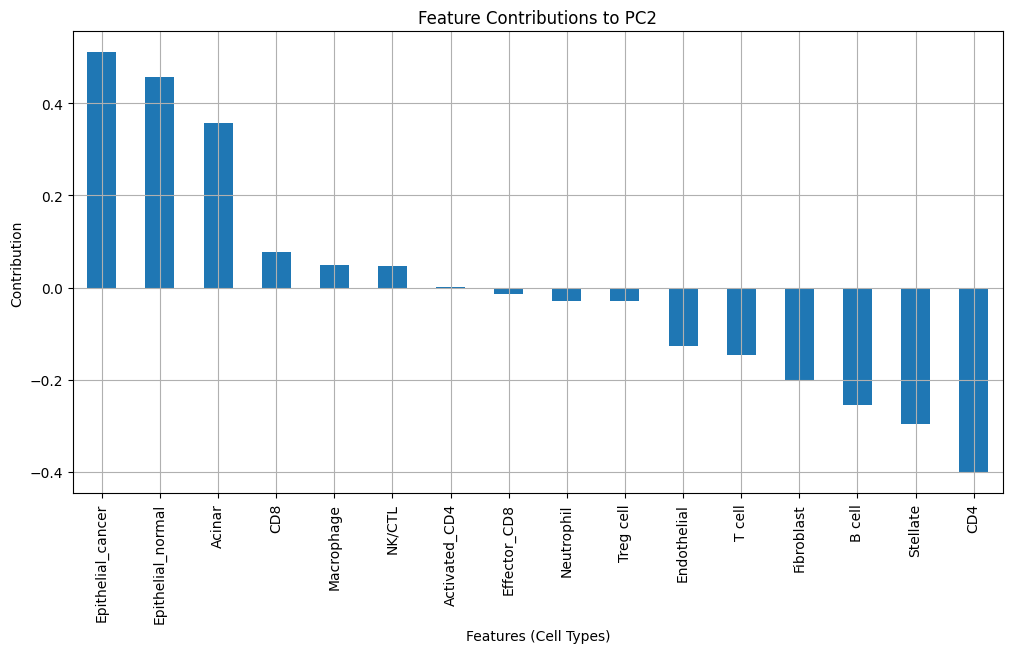

In [17]:
plt.figure(figsize=(12, 6))
loadings['PC2'].sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Contributions to PC2')
plt.xlabel('Features (Cell Types)')
plt.ylabel('Contribution')
plt.grid()
plt.show()

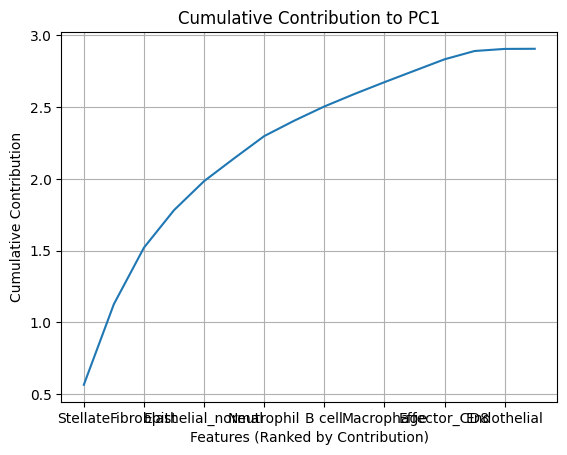

In [16]:
loadings['PC1'].abs().sort_values(ascending=False).cumsum().plot()
plt.title('Cumulative Contribution to PC1')
plt.xlabel('Features (Ranked by Contribution)')
plt.ylabel('Cumulative Contribution')
plt.grid()
plt.show()
